In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


PATH = Path.cwd().parent

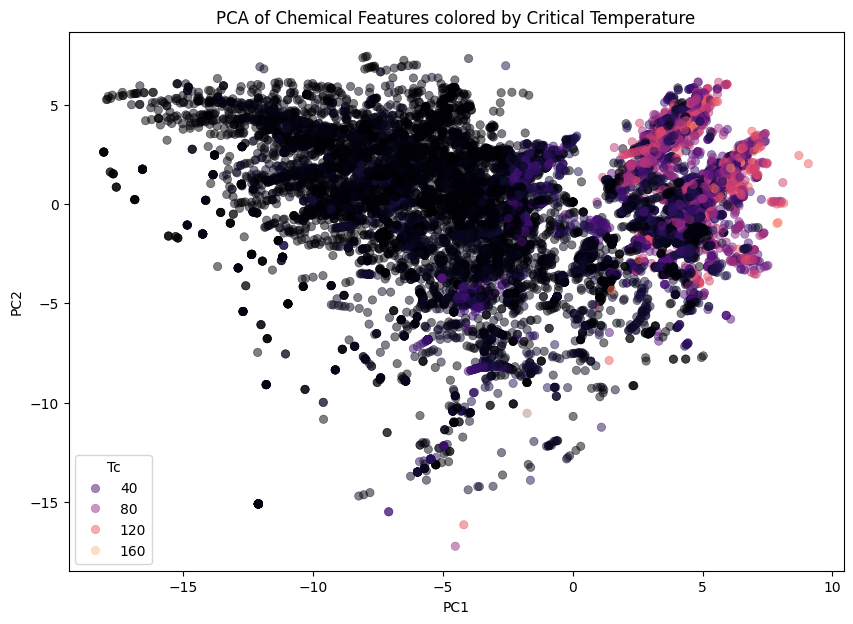

In [8]:
df = pd.read_csv(f"{PATH}/data/super_conductors_raw.csv")

# Standardize features (Crucial for PCA)
features = df.drop('critical_temp', axis=1)
scaled_features = StandardScaler().fit_transform(features)

# Reduce to 2 components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_features)
df_pca = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
df_pca['Tc'] = df['critical_temp']

# Visualize the cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Tc', 
                palette='magma', alpha=0.5, edgecolor=None)
plt.title('PCA of Chemical Features colored by Critical Temperature')
plt.show()

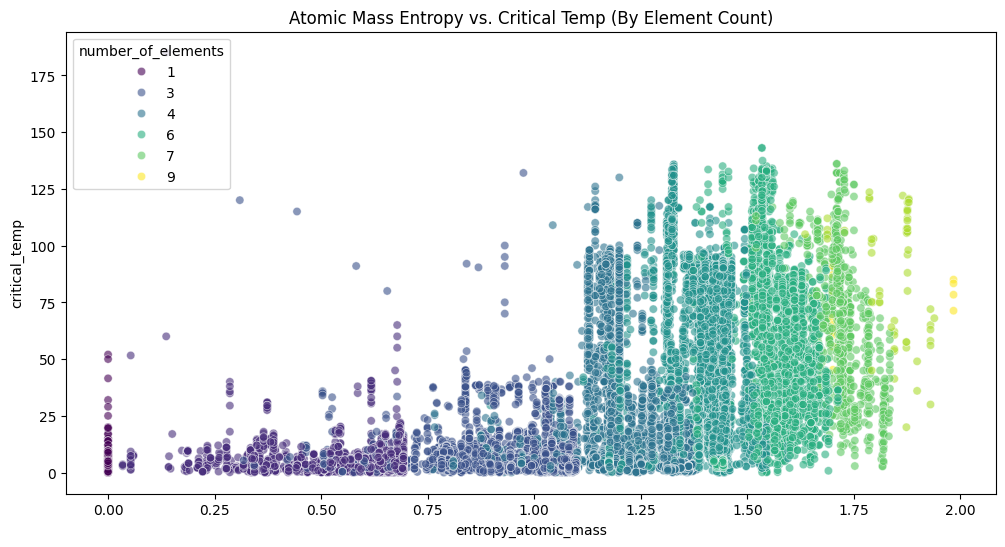

In [9]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='entropy_atomic_mass', y='critical_temp', 
                hue='number_of_elements', palette='viridis', alpha=0.6)
plt.title('Atomic Mass Entropy vs. Critical Temp (By Element Count)')
plt.show()

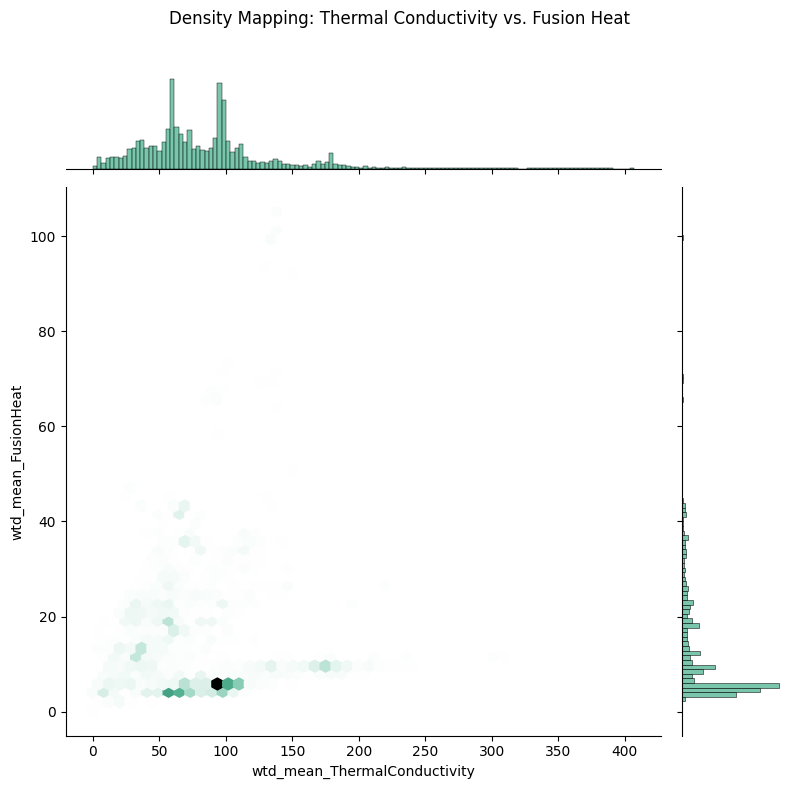

In [10]:
g = sns.jointplot(data=df, x='wtd_mean_ThermalConductivity', y='wtd_mean_FusionHeat', 
                  kind="hex", color="#4CB391", height=8)
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Density Mapping: Thermal Conductivity vs. Fusion Heat')
plt.show()

/tmp/ipykernel_29208/577795767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='valence_group', y='critical_temp', palette='rocket')


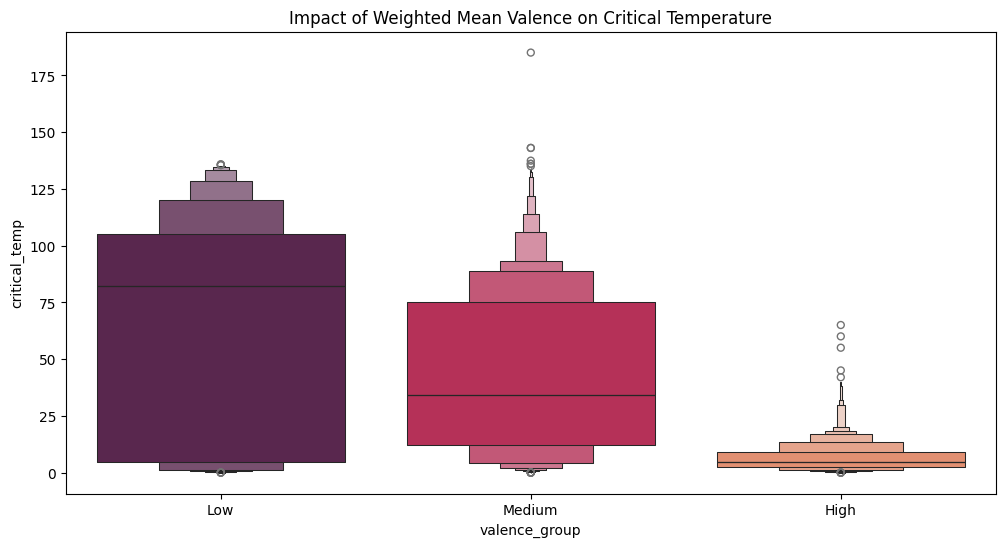

In [11]:
# Create a categorical bin for valence to facilitate faceting
df['valence_group'] = pd.cut(df['wtd_mean_Valence'], bins=[0, 2, 4, 6], labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(12, 6))
sns.boxenplot(data=df, x='valence_group', y='critical_temp', palette='rocket')
plt.title('Impact of Weighted Mean Valence on Critical Temperature')
plt.show()

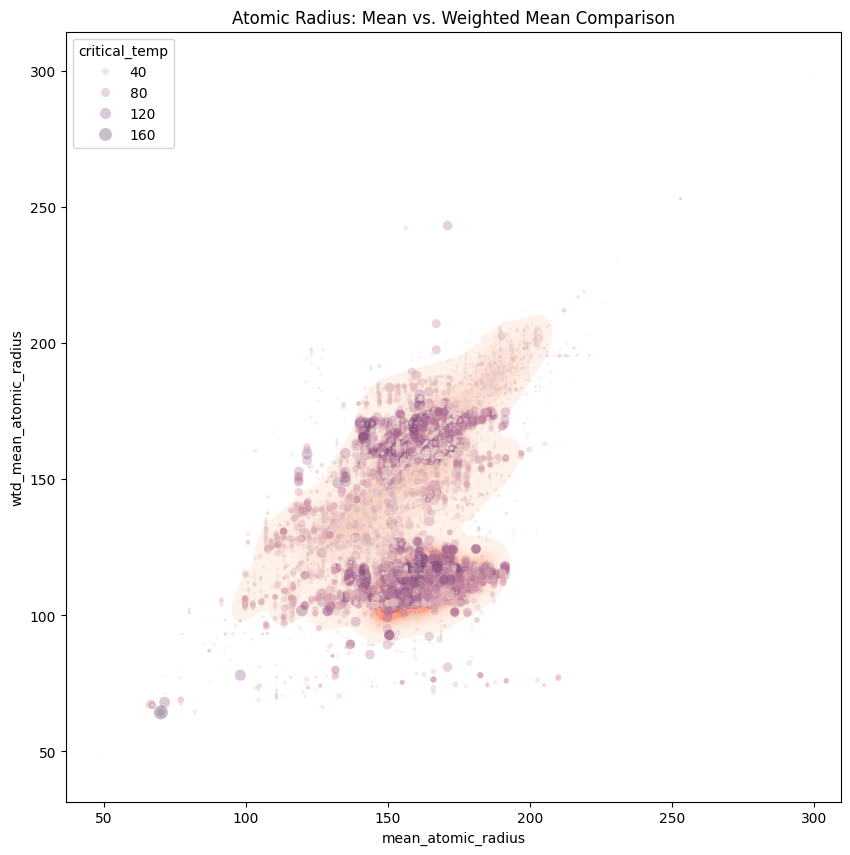

In [12]:
# Comparing atomic radius: mean vs weighted mean
plt.figure(figsize=(10, 10))
sns.kdeplot(data=df, x='mean_atomic_radius', y='wtd_mean_atomic_radius', 
            cmap="Reds", fill=True, thresh=0.05)
sns.scatterplot(data=df, x='mean_atomic_radius', y='wtd_mean_atomic_radius', 
                hue='critical_temp', size='critical_temp', sizes=(1, 100), alpha=0.3)
plt.title('Atomic Radius: Mean vs. Weighted Mean Comparison')
plt.show()

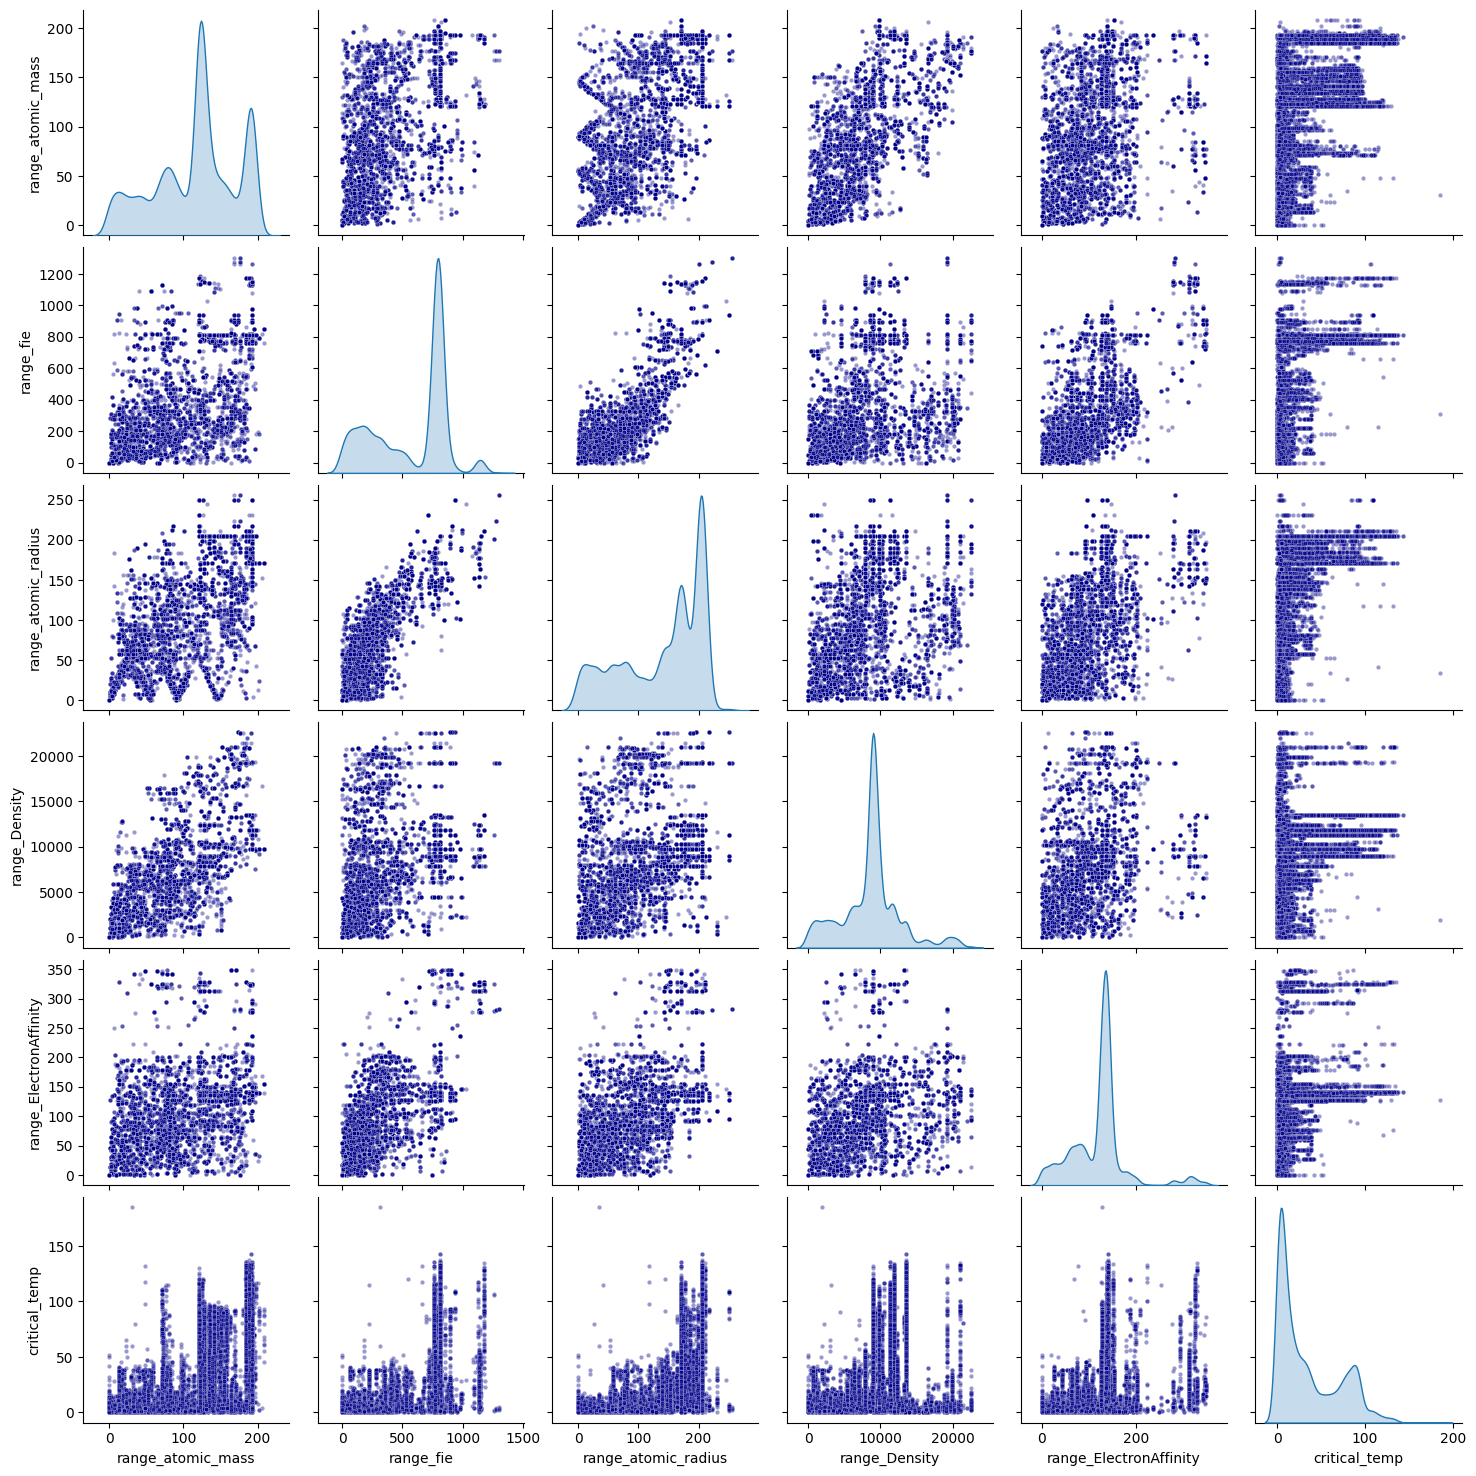

In [13]:
# Selecting 'range' features
range_cols = [col for col in df.columns if 'range' in col and 'wtd' not in col][:5]
range_cols.append('critical_temp')

sns.pairplot(df[range_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 's': 10, 'color': 'darkblue'})
plt.show()

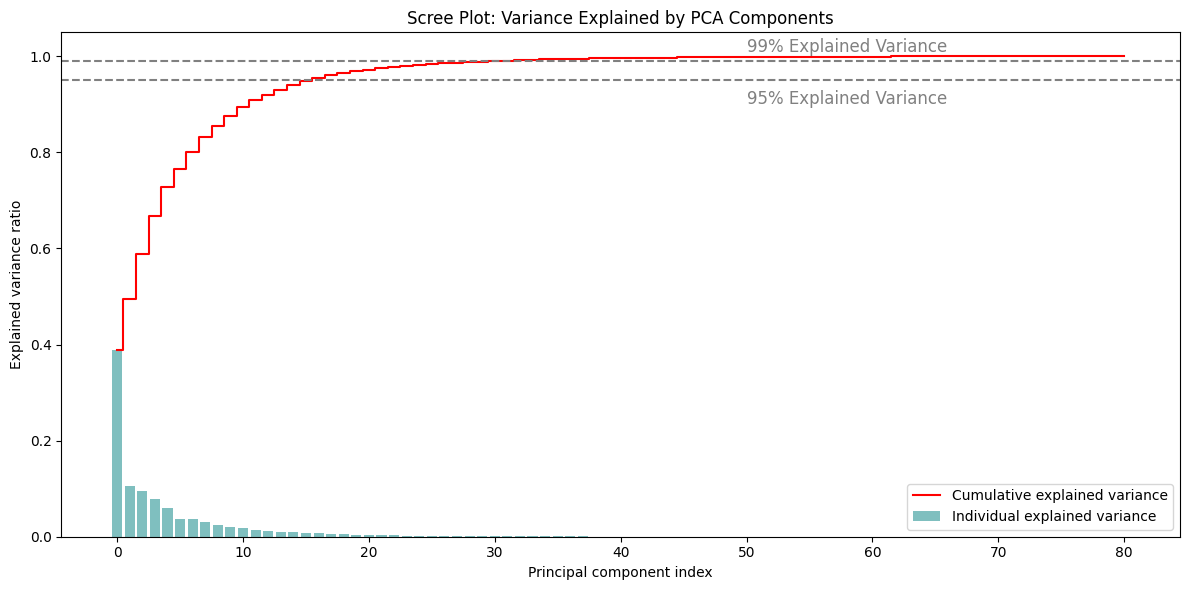

Number of components explaining 95% variance: 17
Number of components explaining 99% variance: 31


In [20]:
# 1. Prepare data (Exclude the target 'critical_temp')
df_pca = pd.read_csv(f"{PATH}/data/super_conductors_raw.csv")
X = df_pca.drop('critical_temp', axis=1)

# 2. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit PCA
pca = PCA()
pca.fit(X_scaled)

# 4. Calculate variance metrics
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# 5. Create the Visualization
plt.figure(figsize=(12, 6))

# Plotting individual explained variance (Bar Chart)
plt.bar(range(0, len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', 
        label='Individual explained variance', color='teal')

# Plotting cumulative explained variance (Step Chart)
plt.step(range(0, len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid', 
         label='Cumulative explained variance', color='red')

# Adding a 95% and 99% threshold line
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.text(50, 0.90, '95% Explained Variance', color = 'gray', fontsize=12)
plt.axhline(y=0.99, color='gray', linestyle='--')
plt.text(50, 1.01, '99% Explained Variance', color = 'gray', fontsize=12)

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot: Variance Explained by PCA Components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Print the number of components needed for 95% and 99% variance
n_95 = np.argmax(cum_sum_eigenvalues >= 0.95) + 1
n_99 = np.argmax(cum_sum_eigenvalues >= 0.99) + 1

print(f"Number of components explaining 95% variance: {n_95}")
print(f"Number of components explaining 99% variance: {n_99}")